# Classificação de dígitos usando CNNs

Este notebook apresenta o funcionamento básico de Redes Neurais Convolucionais (CNNs). Qualquer CNN é formada por duas partes:

1. Um extrator de atributos
2. Uma camada final que classifica os atributos em C classes

Veremos primeiro a utilização de CNNs como extratores de atributos de imagens.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

# Leitura das imagens e dos rótulos
data = np.load("../../dados/mnist.npz")
train_images = data["train_images"]
train_targets = data["train_targets"]
test_images = data["test_images"]
test_targets = data["test_targets"]
print(f"Imagens de treino: {train_images.shape}, Rótulos de treino: {train_targets.shape}")
print(f"Imagens de teste: {test_images.shape}, Rótulos de teste: {test_targets.shape}")

Imagens de treino: (10000, 28, 28), Rótulos de treino: (10000,)
Imagens de teste: (1000, 28, 28), Rótulos de teste: (1000,)


## Definição e aplicação do modelo

No Pytorch, uma CNN é definida por uma classe do Python que descreve quais são as camadas da rede e como elas são aplicadas em uma imagem

In [2]:
class Model(torch.nn.Module):
    """Modelo CNN para extração de atributos de dígitos."""
    def __init__(self):
        super().__init__()

        # Definição de uma camada convolucional com 8 filtros de tamanho 13x13 e padding para 
        # manter o tamanho da imagem
        self.conv = torch.nn.Conv2d(1, 8, kernel_size=13, padding=13//2)

    def forward(self, img):
        """O método forward define como a imagem de entrada é processada pela rede. Como
        este modelo possui apenas uma camada, apenas essa camada é aplicada."""
        img_filt = self.conv(img)

        return img_filt
    
model = Model()
# Desabilita o treinamento do modelo
model.requires_grad_(False)

Model(
  (conv): Conv2d(1, 8, kernel_size=(13, 13), stride=(1, 1), padding=(6, 6))
)

O modelo é composto por 8 filtros criados aleatoriamente:

In [3]:
filtros = model.conv.weight
print(f"Quantidade e tamanho dos filtros: {filtros.shape}")
print(f"Valores do primeiro filtro:\n{filtros[0, 0]}")

Quantidade e tamanho dos filtros: torch.Size([8, 1, 13, 13])
Valores do primeiro filtro:
tensor([[-0.0285,  0.0095,  0.0396, -0.0260, -0.0415,  0.0078,  0.0385, -0.0369,
          0.0632,  0.0472, -0.0737, -0.0161, -0.0517],
        [-0.0374, -0.0630, -0.0088, -0.0474, -0.0562, -0.0522,  0.0733,  0.0159,
          0.0016, -0.0174, -0.0170, -0.0186, -0.0226],
        [-0.0481,  0.0604,  0.0040, -0.0014,  0.0030,  0.0143, -0.0630,  0.0098,
         -0.0128,  0.0473, -0.0137, -0.0160, -0.0092],
        [-0.0728, -0.0459, -0.0669, -0.0462, -0.0473, -0.0142,  0.0253, -0.0490,
          0.0257,  0.0451,  0.0732, -0.0161, -0.0769],
        [ 0.0385, -0.0510,  0.0681,  0.0384,  0.0700, -0.0170,  0.0260, -0.0476,
          0.0051, -0.0014,  0.0072, -0.0748,  0.0758],
        [-0.0574,  0.0230, -0.0614,  0.0408,  0.0261, -0.0232,  0.0746,  0.0623,
          0.0529,  0.0753, -0.0504,  0.0078, -0.0743],
        [-0.0303,  0.0607,  0.0417, -0.0234,  0.0724,  0.0231, -0.0559, -0.0440,
          0.02

Os filtros criados são aleatórios. É possível carregarmos valores específicos desses filtros gerados através do treinamento da rede para o dataset MNIST. Não veremos como treinar a rede, apenas como aplicá-la nos dados.

In [4]:
model.load_state_dict(torch.load("../../dados/mnist_cnn_features.pt"))

<All keys matched successfully>

In [5]:
def apply_model(model, img):
    """Aplicação do modelo a uma imagem."""

    # torch.from_numpy converte a imagem para um tensor do PyTorch.
    # Toda imagem de entrada precisa ter uma dimensão representando o canal da imagem. O
    # comando unsqueeze(0) transforma a imagem de 28x28 para 1x28x28, ou seja, adiciona uma 
    # dimensão de canal no começo do array.
    img_pt = torch.from_numpy(img).unsqueeze(0)
    # Divide por 255 para normalizar os valores dos pixels para a faixa [0, 1], o que é uma 
    # prática comum em redes neurais.
    img_pt = img_pt / 255
    # Aplica o modelo
    img_filt = model(img_pt)

    return img_filt

img_filt = apply_model(model, train_images[0])
print(f"Tamanho da saída da rede: {img_filt.shape}")

Tamanho da saída da rede: torch.Size([8, 28, 28])


A rede possui 8 filtros. Cada filtro é aplicado na imagem, gerando 8 imagens de saída de tamanho 28x28

## Uso da CNN para extração de atributos e classificação

A CNN permite extrair 8 atributos de cada imagem do conjunto de dados. Veremos como extrair atributos de todas as imagens e usá-los para classificação.

In [6]:
def extract_features(model, images):
    """Extrai atributos de um conjunto de imagens usando o modelo."""

    all_features = []
    for img in images:
        img_filt = apply_model(model, img)

        # A função amax calcula o valor máximo ao longo das dimensões especificadas. Neste caso,
        # estamos calculando o valor máximo para cada canal (filtro) ao longo das dimensões 
        # espaciais (altura e largura) da imagem filtrada. O resultado é um vetor de 8 valores, 
        # um para cada filtro, representando a resposta máxima de cada filtro para a imagem de 
        # entrada. Portanto, podemos interpretar esses valores como os atributos extraídos da 
        # imagem, onde cada atributo corresponde à resposta máxima de um filtro específico.
        img_features = img_filt.amax(dim=(1,2))

        all_features.append(img_features)
        
    return np.array(all_features)

train_features = extract_features(model, train_images)
test_features = extract_features(model, test_images)
print(train_features.shape)

(10000, 8)


Utilizaremos a regressão logística para classificação dos dados. Esse classificador é extremamente simples e possibilita separar lienarmente os dados em classes.

In [7]:
from sklearn.linear_model import LogisticRegression

# Treina o classificador
classifier = LogisticRegression(max_iter=1000)
classifier.fit(train_features, train_targets)
# Testa o classificador
result = classifier.predict(test_features)
num_equal = (result==test_targets).mean()
print(f"Accurácia: {100*num_equal}%")

Accurácia: 98.5%


## Interpretação dos filtros gerados pela rede

Podemos visualizar os filtros e as saídas deles para entender como é feito o processamento da rede.

Primeiro, vamos visualizar os filtros, cada um possuindo tamanho 13x13:

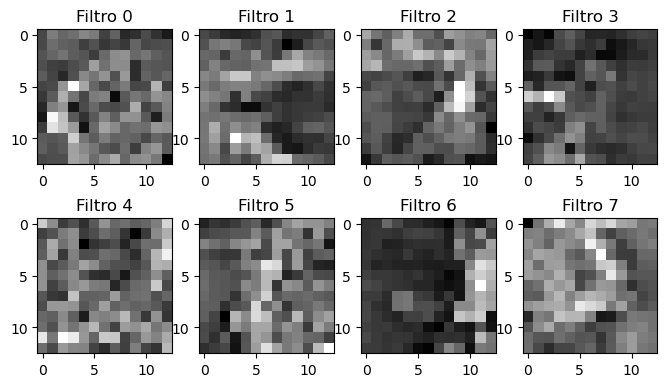

In [8]:
fig, axs = plt.subplots(2, 4, figsize=(8,4.5))
axs = axs.reshape(-1)
for idx in range(8):
    axs[idx].imshow(model.conv.weight[idx,0], "gray")
    axs[idx].set_title(f"Filtro {idx}")

Visualização do resultado da convolução de cada filtro com diferentes imagens:

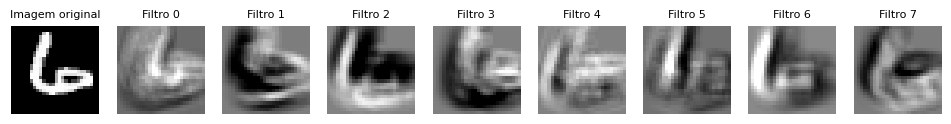

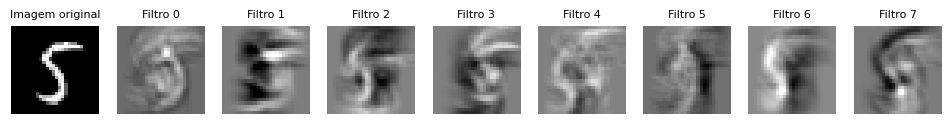

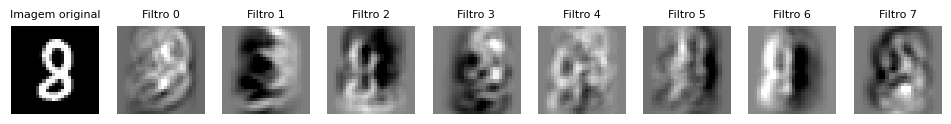

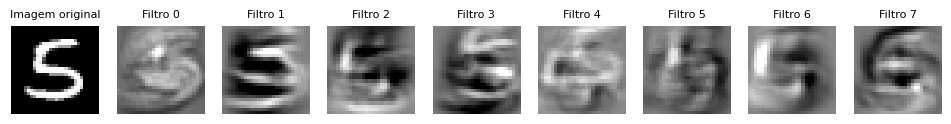

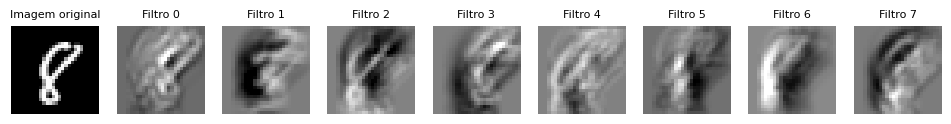

In [9]:
for idx in range(5):
    img = train_images[idx]
    img_filt = apply_model(model, img)

    fig, axs = plt.subplots(1,9, figsize=(12,3))
    axs[0].imshow(img, "gray")
    axs[0].set_title(f"Imagem original", size=8)
    axs[0].set_axis_off()
    for channel in range(8):
        ax = axs[channel+1]
        ax.imshow(img_filt[channel], "gray", vmin=-10, vmax=10)
        ax.set_title(f"Filtro {channel}", size=8)
        ax.set_axis_off()    

## CNN de classificação

Na prática, uma CNN é sempre formada por camadas que extraem os atributos e uma última camada que essencialmente faz o papel de um classificador logístico. Essa camada é chamada de `linear`.

In [10]:
class Model(nn.Module):
    """Modelo para classificação de dígitos."""
    def __init__(self):
        super().__init__()

        # 8 filtros de convolução
        self.conv = nn.Conv2d(1, 8, kernel_size=13, padding=13//2)
        # Camada linear que recebe 8 valores e gera 10 valores de saída, um para cada classe 
        # de dígito (0-9)
        self.fc = nn.Linear(8, 10)

    def forward(self, img):
        img_filt = self.conv(img)
        # Atributos extraídos pela camada convolucional, como visto acima
        features = img_filt.amax(dim=(1,2))
        # Classificação dos dígitos com base nos atributos extraídos pela camada convolucional
        x = self.fc(features)

        return x
    
model = Model()
# Carrega os pesos de uma rede CNN de classificação já treinada no conjunto de dados MNIST
model.load_state_dict(torch.load("../../dados/mnist_cnn.pt"))

<All keys matched successfully>

In [11]:
def predict_classes(model, images, targets):
    """Realiza a predição das classes para um conjunto de imagens de teste usando o modelo."""
        
    predictions = np.zeros_like(targets)
    for i, (img, target) in enumerate(zip(images, targets)):
        
        output = apply_model(model, img)

        # A saída do modelo possui 10 valores, um para cada classe de dígito. Cada valor output[i]
        # representa a confiança do modelo de que a imagem pertence à classe i. Para obter a classe 
        # predita, usamos a função argmax, que retorna o índice do valor máximo na saída do modelo
        pred = output.argmax().item()
        # Armazena a classe predita
        predictions[i] = pred

    return predictions

predictions = predict_classes(model, test_images, test_targets)
accuracy = (predictions == test_targets).mean()
print(f"Acurácia: {100*accuracy}%")

Acurácia: 100.0%
